<a href="https://colab.research.google.com/github/ENRIQUESPECTER/Mineria-de-Datos/blob/main/REGRESI%C3%93N_LINEAL_EJERCICIOS/Regresion_Lineal_Ejercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análisis de regresión lineal: Horas de esturio vs Calificaciones
Predecir calificaciones basadas en horas de estudio usando el archivo calificaciones.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split #Para dividir los datos en train/test
from sklearn.metrics import mean_squared_error, r2_score #Metricas de evaluación


In [ ]:
#Carga y exploración inicial de datos
publicidad = pd.read_csv('PublicidadVentas.csv')
publicidad.head()


,Inversion,Ventas
0,1.2,180
1,1.5,210
2,1.8,250
3,2.0,280
4,2.2,300


In [ ]:
examenes = pd.read_csv('PracticaExamenes.csv')
examenes.head()

,horas,puntuacion
0,3,64
1,4,67
2,6,76
3,3,65
4,5,72


In [ ]:
seguros = pd.read_csv('EdadSeguros.csv')
seguros.head()

,Edad,Costo
0,18,22
1,22,24
2,23,55
3,25,27
4,27,85


**Problema 1: El departamento de marketing de una empresa registró durante 100 meses la inversión en publicidad digital (en miles de dólares) y las unidades vendidas. Necesitan cuantificar cómo afecta el gasto en publicidad a las ventas para optimizar su presupuesto.**

**Lo que debe hacer el código:**
**Importar y procesar los datos históricos**

**Ajustar un modelo de regresión lineal que relacione inversión con ventas**

**Evaluar la calidad del modelo mediante MSE y R²**

**Visualizar la relación con un gráfico profesional con ejes etiquetados**

**Implementar una función para estimar ventas esperadas según posible inversión**

**Mostrar la ecuación del modelo en el gráfico**

In [ ]:
#Información basica del dataframe
publicidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Inversion  70 non-null     float64
 1   Ventas     70 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.2 KB


In [ ]:
#Estadisticas descriptivas para entender la distribucion
publicidad.describe()

,Inversion,Ventas
count,70.000000,70.000000
mean,9.880000,908.000000
std,5.093605,410.071044
min,1.200000,180.000000
25%,5.575000,565.000000
50%,9.900000,910.000000
75%,14.150000,1255.000000
max,18.500000,1600.000000


In [ ]:
#Seleccionamos las variables:
#X: independiente (predictora) - Gasto / Inversion
#y: dependiente (a predecir) - Ventas

#Extraemos los valores como arrays de numpy para el modelo
X = publicidad[['Inversion']].values
Y = publicidad[['Ventas']].values

In [ ]:
#dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%)
#test_size=0.2 El 20% de los datos va al test, el 80% al train
#train_test_split divide los datos aleatoriamente
#random_state =42 asegura que la division sea reproducible
#Fija una "semilla" para que la división sea siempre igual cada vez que corras el código

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
#Creación y entrenamiento del modelo
#Creamos una instancia del modelo de regresión lineal
modelo = LinearRegression()

#Entrenamos el modelo con los datos de entrenamiento
#El metodo fit() ajusta los parametros del modelo
modelo.fit(X_train, Y_train)

LinearRegression()

In [ ]:
#Evaluación del modelo
#predict hace la prediccion de los datos de test
#y_pred es la prediccion de las calificaciones
y_pred = modelo.predict(X_test)


In [ ]:
#Calculamos las mestricas de evaluacion MSE , R2

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

In [ ]:
#Mostramos los resultados del modelo de regresión lineal
print(f"Coeficiente (pendiente): {modelo.coef_[0][0]:.2f}. Por inversion las ventas aumentan en {modelo.coef_[0][0]:.2f} puntos")
print(f"Intercepto: {modelo.intercept_[0]:.2f}. Cuando no se Invierte en publicidad, las ventas esperadas son {modelo.intercept_[0]:.2f} puntos")
print(f"Error cuadratico medio (MSE): {mse:.2f}. El error promedio al cuadrado entre predicciones y valores reales es {mse:.2f}")
porcentaje_variabilidad = r2 * 100
print(f"Coeficiente de determinacion (R2): {r2:.2f}. El porcentaje de variabilidad en las ventas es {porcentaje_variabilidad:.2f}%")


Coeficiente (pendiente): 80.35. Por inversion las ventas aumentan en 80.35 puntos
Intercepto: 114.68. Cuando no se Invierte en publicidad, las ventas esperadas son 114.68 puntos
Error cuadratico medio (MSE): 96.08. El error promedio al cuadrado entre predicciones y valores reales es 96.08
Coeficiente de determinacion (R2): 1.00. El porcentaje de variabilidad en las ventas es 99.94%


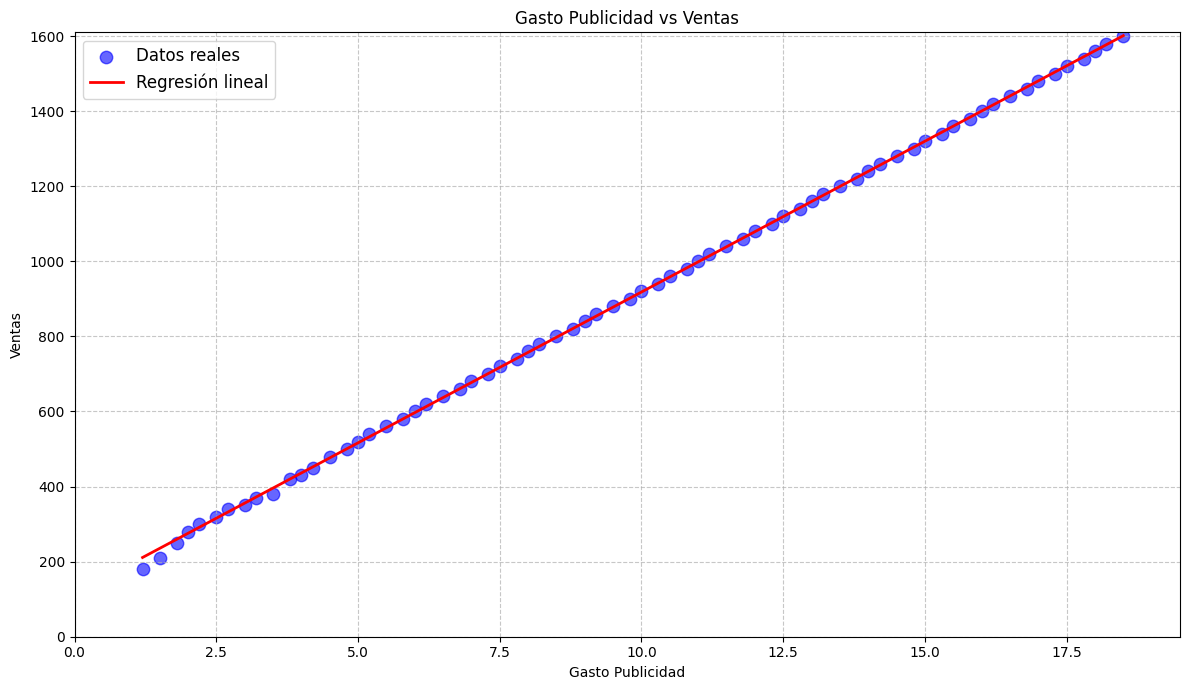

In [ ]:
#Visualización de los resultados
plt.figure(figsize=(12,7))
plt.scatter(X,Y, color='blue', label='Datos reales', alpha=0.6, s=80)
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Regresión lineal')

plt.title('Gasto Publicidad vs Ventas')
plt.xlabel('Gasto Publicidad')
plt.ylabel('Ventas')
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

#Ajustamos los limites
plt.xlim(0, np.max(X) + 1)
plt.ylim(0, np.max(Y) + 10)

plt.tight_layout()
plt.show()


In [ ]:
#Prediccion con datos nuevos
horas_ejemplo = np.array([[1],[3],[5]])

for horas in horas_ejemplo:
  prediccion = modelo.predict(horas.reshape(-1,1))
  print(f"Prediccion para {horas[0]} inversion: {prediccion[0][0]:.2f} puntos")

Prediccion para 1 inversion: 195.03 puntos
Prediccion para 3 inversion: 355.73 puntos
Prediccion para 5 inversion: 516.43 puntos


**Problema 2: Una aseguradora tiene datos de 120 clientes con su edad y el costo mensual de su póliza. Requieren modelar cómo aumenta el costo con la edad para ajustar sus tarifas.**

**Lo que debe hacer el código:**

**Cargar los datos demográficos y de costos**

**Verificar la relación lineal mediante un gráfico inicial**

**Entrenar el modelo de regresión y extraer sus parámetros**

**Calcular intervalos de confianza para las predicciones**

**Crear una visualización que muestre: Puntos con los datos reales y línea de regresión**

**Generar una tabla con predicciones para edades clave (30, 40, 50, 60 años)**

In [ ]:
#Información basica del dataframe
seguros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Edad    80 non-null     int64
 1   Costo   80 non-null     int64
dtypes: int64(2)
memory usage: 1.4 KB


In [ ]:
#Estadisticas descriptivas para entender la distribucion
seguros.describe()

,Edad,Costo
count,80.00000,80.000000
mean,53.75000,52.162500
std,15.38987,24.120186
min,18.00000,5.000000
25%,42.75000,35.000000
50%,56.00000,55.000000
75%,66.00000,65.750000
max,79.00000,96.000000


In [ ]:
#Seleccionamos las variables:
#X: independiente (predictora) - Edad
#y: dependiente (a predecir) - Costo

#Extraemos los valores como arrays de numpy para el modelo
X = seguros[['Edad ']].values
Y = seguros[['Costo']].values

In [ ]:
#dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%)
#test_size=0.2 El 20% de los datos va al test, el 80% al train
#train_test_split divide los datos aleatoriamente
#random_state =42 asegura que la division sea reproducible
#Fija una "semilla" para que la división sea siempre igual cada vez que corras el código

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
#Creación y entrenamiento del modelo
#Creamos una instancia del modelo de regresión lineal
modelo = LinearRegression()

#Entrenamos el modelo con los datos de entrenamiento
#El metodo fit() ajusta los parametros del modelo
modelo.fit(X_train, Y_train)

LinearRegression()

In [ ]:
#Evaluación del modelo
#predict hace la prediccion de los datos de test
#y_pred es la prediccion de las calificaciones
y_pred = modelo.predict(X_test)


In [ ]:
#Calculamos las mestricas de evaluacion MSE , R2

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

In [ ]:
#Mostramos los resultados del modelo de regresión lineal
print(f"Coeficiente (pendiente): {modelo.coef_[0][0]:.2f}. Por edad el costo mensual de poliza aumenta en {modelo.coef_[0][0]:.2f} puntos")
print(f"Intercepto: {modelo.intercept_[0]:.2f}. Cuando la edad no influye, el costo mensual esperado es {modelo.intercept_[0]:.2f} puntos")
print(f"Error cuadratico medio (MSE): {mse:.2f}. El error promedio al cuadrado entre predicciones y valores reales es {mse:.2f}")
porcentaje_variabilidad = r2 * 100
print(f"Coeficiente de determinacion (R2): {r2:.2f}. El porcentaje de variabilidad en costos es {porcentaje_variabilidad:.2f}%")


Coeficiente (pendiente): 0.45. Por edad el costo mensual de poliza aumenta en 0.45 puntos
Intercepto: 26.44. Cuando la edad no influye, el costo mensual esperado es 26.44 puntos
Error cuadratico medio (MSE): 463.29. El error promedio al cuadrado entre predicciones y valores reales es 463.29
Coeficiente de determinacion (R2): 0.03. El porcentaje de variabilidad en costos es 3.48%


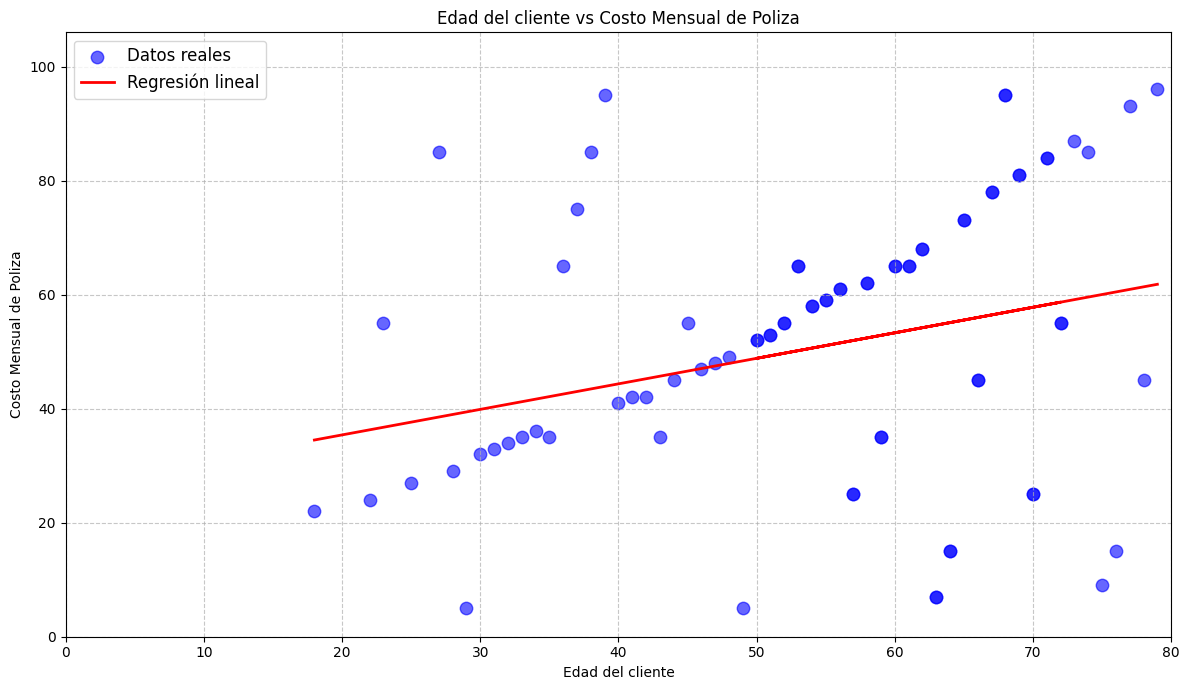

In [ ]:
#Visualización de los resultados
plt.figure(figsize=(12,7))
plt.scatter(X,Y, color='blue', label='Datos reales', alpha=0.6, s=80)
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Regresión lineal')

plt.title('Edad del cliente vs Costo Mensual de Poliza')
plt.xlabel('Edad del cliente')
plt.ylabel('Costo Mensual de Poliza')
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

#Ajustamos los limites
plt.xlim(0, np.max(X) + 1)
plt.ylim(0, np.max(Y) + 10)

plt.tight_layout()
plt.show()


In [ ]:
#Prediccion con datos nuevos
horas_ejemplo = np.array([[1],[3],[5]])

for horas in horas_ejemplo:
  prediccion = modelo.predict(horas.reshape(-1,1))
  print(f"Prediccion para {horas[0]} costo: {prediccion[0][0]:.2f} puntos")

Prediccion para 1 costo: 26.89 puntos
Prediccion para 3 costo: 27.78 puntos
Prediccion para 5 costo: 28.68 puntos


**Problema 3: Un instructor de programación recolectó datos de 150 estudiantes registrando las horas de práctica semanal y sus puntuaciones finales en el examen. Quiere determinar si existe una relación lineal entre estas variables y poder predecir la puntuación esperada según las horas de práctica.**

**Lo que debe hacer el código:**

**Cargar y explorar los datos del archivo CSV**

**Realizar un análisis de regresión lineal simple**

**Determinar la ecuación de la recta de regresión (pendiente e intercepto)**

**Calcular e interpretar el R² (coeficiente de determinación)**

**Visualizar la relación con un gráfico de dispersión y la línea de regresión**

**Permitir hacer predicciones para nuevas cantidades de horas de práctica**

In [ ]:
#Información basica del dataframe
examenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   horas       150 non-null    int64
 1   puntuacion  150 non-null    int64
dtypes: int64(2)
memory usage: 2.5 KB


In [ ]:
#Estadisticas descriptivas para entender la distribucion
examenes.describe()

,horas,puntuacion
count,150.000000,150.000000
mean,3.513333,65.360000
std,1.759868,9.277439
min,1.000000,50.000000
25%,2.000000,58.000000
50%,4.000000,66.000000
75%,5.000000,73.000000
max,6.000000,80.000000


In [ ]:
#Seleccionamos las variables:
#X: independiente (predictora) - Edad
#y: dependiente (a predecir) - Costo

#Extraemos los valores como arrays de numpy para el modelo
X = examenes[['horas']].values
Y = examenes[['puntuacion']].values

In [ ]:
#dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%)
#test_size=0.2 El 20% de los datos va al test, el 80% al train
#train_test_split divide los datos aleatoriamente
#random_state =42 asegura que la division sea reproducible
#Fija una "semilla" para que la división sea siempre igual cada vez que corras el código

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
#Creación y entrenamiento del modelo
#Creamos una instancia del modelo de regresión lineal
modelo = LinearRegression()

#Entrenamos el modelo con los datos de entrenamiento
#El metodo fit() ajusta los parametros del modelo
modelo.fit(X_train, Y_train)

LinearRegression()

In [ ]:
#Evaluación del modelo
#predict hace la prediccion de los datos de test
#y_pred es la prediccion de las calificaciones
y_pred = modelo.predict(X_test)


In [ ]:
#Calculamos las mestricas de evaluacion MSE , R2

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

In [ ]:
#Mostramos los resultados del modelo de regresión lineal
print(f"Coeficiente (pendiente): {modelo.coef_[0][0]:.2f}. Por horas de práctica la puntuación aumenta en {modelo.coef_[0][0]:.2f} puntos")
print(f"Intercepto: {modelo.intercept_[0]:.2f}. Cuando no hay horas (0), la puntuación es {modelo.intercept_[0]:.2f} puntos")
print(f"Error cuadratico medio (MSE): {mse:.2f}. El error promedio al cuadrado entre predicciones y valores reales es {mse:.2f}")
porcentaje_variabilidad = r2 * 100
print(f"Coeficiente de determinacion (R2): {r2:.2f}. El porcentaje de variabilidad en puntuación es {porcentaje_variabilidad:.2f}%")


Coeficiente (pendiente): 5.17. Por horas de práctica la puntuación aumenta en 5.17 puntos
Intercepto: 47.21. Cuando no hay horas (0), la puntuación es 47.21 puntos
Error cuadratico medio (MSE): 1.89. El error promedio al cuadrado entre predicciones y valores reales es 1.89
Coeficiente de determinacion (R2): 0.98. El porcentaje de variabilidad en puntuación es 98.37%


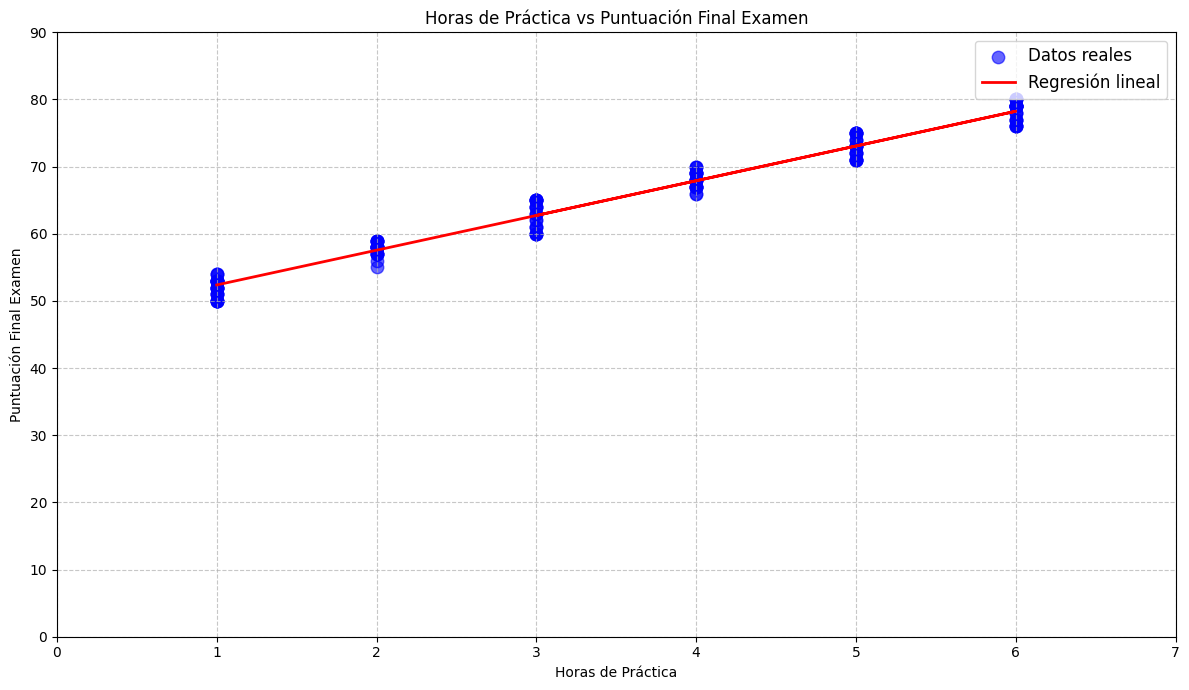

In [ ]:
#Visualización de los resultados
plt.figure(figsize=(12,7))
plt.scatter(X,Y, color='blue', label='Datos reales', alpha=0.6, s=80)
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Regresión lineal')

plt.title('Horas de Práctica vs Puntuación Final Examen')
plt.xlabel('Horas de Práctica')
plt.ylabel('Puntuación Final Examen')
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

#Ajustamos los limites
plt.xlim(0, np.max(X) + 1)
plt.ylim(0, np.max(Y) + 10)

plt.tight_layout()
plt.show()


In [ ]:
#Prediccion con datos nuevos
horas_ejemplo = np.array([[1],[3],[5]])

for horas in horas_ejemplo:
  prediccion = modelo.predict(horas.reshape(-1,1))
  print(f"Prediccion para {horas[0]} costo: {prediccion[0][0]:.2f} puntos")

Prediccion para 1 costo: 52.38 puntos
Prediccion para 3 costo: 62.73 puntos
Prediccion para 5 costo: 73.08 puntos
